# Exercise: ParmEst

In this exercise, you will practice using ParmEst to estimate four parameters ($U_a$, $U_b$, $C_p^H$, $C_p^S$) in the TCLab model using the step test data. We [previously estimated these parameters using the sine test data](../notebooks/parmest.ipynb).

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"
else:
    import os

    if "exercise_solutions" in os.getcwd():
        # Add the "notebooks" folder to the path
        # This is needed for running the solutions from a separate folder
        # You only need this if you run locally
        sys.path.append('../notebooks')

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
)

# set default number of states in the TCLab model
number_tclab_states = 2

import logging
logging.basicConfig(level=logging.ERROR)

parmest_logger = logging.getLogger("pyomo.contrib.parmest.parmest")
parmest_logger.setLevel(logging.ERROR)

## Load and explore experimental data (sine test)

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


Make two plots to visualize the temperature and heat power data as a function of time.

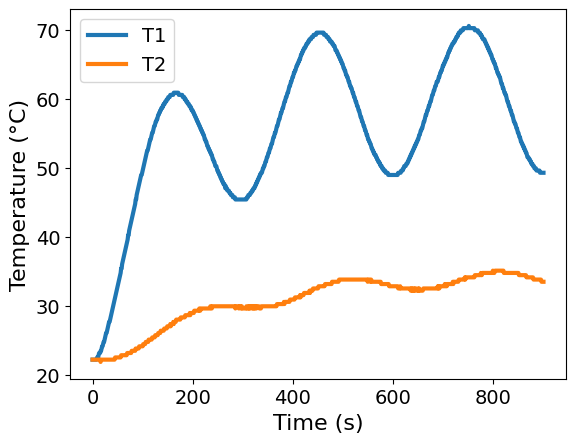

In [3]:
### BEGIN SOLUTION
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')
### END SOLUTION

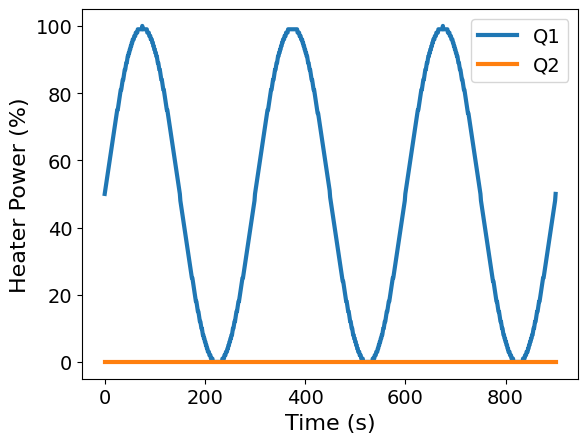

In [4]:
### BEGIN SOLUTION
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')
### END SOLUTION

We'll now store the data in this custom *data class* objective. This is a nice trick to help keep data organized, but it is NOT required to use ParmEst or Pyomo data. Alternatively, we could just use a pandas DataFrame.

In [5]:
tc_data = TC_Lab_data(
    name="Step Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

Our custom data class has a method to export the data as a Pandas Data Frame.

In [6]:
tc_data.to_data_frame().head()

,time,T1,u1,P1,TS1_data,T2,u2,P2,TS2_data,Tamb
0,0.00,22.2,50,200,None,22.2,0,200,None,22.2
1,1.01,22.2,51,200,None,22.2,0,200,None,22.2
2,2.01,22.2,52,200,None,22.2,0,200,None,22.2
3,3.00,22.2,53,200,None,22.2,0,200,None,22.2
4,4.01,22.2,54,200,None,22.2,0,200,None,22.2


## Parameter estimation with ParmEst

Now for the main event: performing nonlinear least squares with `ParmEst`.



In [7]:
import pyomo.contrib.parmest.parmest as parmest

# Solver options used for all parmest estimation problems in this notebook
solver_options = {
                  'linear_solver': 'ma57', 
                  'max_iter': 1000,
                  'max_cpu_time': 30
                  }

# First, we define an Experiment object within parmest
### BEGIN SOLUTION
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states, reparam=True)
### END SOLUTION

# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
### BEGIN SOLUTION
pest = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', tee=True, solver_options=solver_options)

obj, theta = pest.theta_est()
### END SOLUTION

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000
max_cpu_time=30


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-

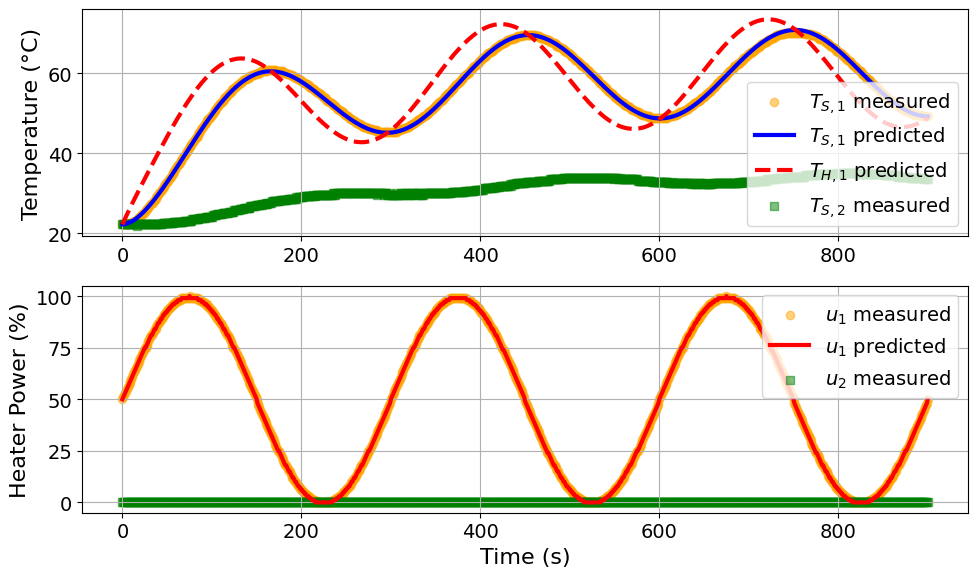

Model parameters:
Beta_1 = 0.0133 Watts/degC
Beta_2 = 0.0216 Watts/degC
Beta_3 = 0.0287 Watts/degC
Beta_4 = 0.0102 Joules/degC
 


In [8]:
parmest_regression_results = extract_plot_results(
    tc_data, pest.ef_instance.exp_scenarios[0], reparam=True
)

In [9]:
# Calculate back the original parameters from the reparameterized ones
# Default values for alpha and P1
alpha = 0.00016  # K/W, heater efficiency
P1 = 200         # W, maximum heater power


inv_CpH = theta["beta_4"] / (alpha * P1)
Ua = theta["beta_1"] / inv_CpH
Ub = theta["beta_2"] / inv_CpH
inv_CpS = Ub / theta["beta_3"] 

print("Estimated parameters:")
print(f"Ua: {Ua:.6f} W/K")
print(f"Ub: {Ub:.6f} W/K")
print(f"CpH: {1/inv_CpH:.6f} J/(K*kg)")
print(f"CpS: {1/inv_CpS:.6f} J/(K*kg)")



Estimated parameters:
Ua: 0.041705 W/K
Ub: 0.067820 W/K
CpH: 3.141381 J/(K*kg)
CpS: 0.423385 J/(K*kg)


**Discussion**: How do these results compare to our [previous analysis](../notebooks/parmest.ipynb)?

## Calculate the covariance

In [10]:
cov = pest.cov_est()
print("Covariance matrix of parameter estimates:")
print(cov)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

## Multistart optimization

Use multistart optimization with sobol sampling on the reformulated model.

In [11]:
pest_sobol = parmest.Estimator([TC_Lab_sine_exp, ], 
                               obj_function='SSE', 
                               tee=True,
                               solver_options=solver_options)



# Set some common options for all multistart estimation runs
common_multistart_options = {
    'n_restarts': 15,
    'seed': 532,
    'save_results': False,
}

In [12]:
### BEGIN SOLUTION
results_df_sobol, best_theta_sobol, best_obj_sobol = pest_sobol.theta_est_multistart(
        multistart_sampling_method="sobol_sampling",
        n_restarts=common_multistart_options['n_restarts'],
        seed=common_multistart_options['seed'],
        save_results=common_multistart_options['save_results'],
)
### END SOLUTION

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000
max_cpu_time=30


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-

In [13]:
# Analyze results
print("Best parameter estimates from Sobol sampling multistart:")
print(best_theta_sobol)
print(f"Best objective value from Sobol sampling multistart: {best_obj_sobol}")

# Round the objective values to a reasonable number of decimal places for counting unique minima
results_df_sobol['final objective'] = results_df_sobol['final objective'].round(5)

num_unique_minima_sobol = len(results_df_sobol['final objective'].unique())
print(f"Number of unique minima found with Sobol sampling: {num_unique_minima_sobol}")


Best parameter estimates from Sobol sampling multistart:
{'beta_1': 0.007895540933404247, 'beta_2': 0.00740222967157357, 'beta_3': 0.048281511545718324, 'beta_4': 0.006058176708734274}
Best objective value from Sobol sampling multistart: 53.77399284580809
Number of unique minima found with Sobol sampling: 1


In [14]:
# Calculate back the original parameters from the reparameterized ones 
# for the best Sobol sampling result
inv_CpH = best_theta_sobol["beta_4"] / (alpha * P1)
Ua = best_theta_sobol["beta_1"] / inv_CpH
Ub = best_theta_sobol["beta_2"] / inv_CpH
inv_CpS = Ub / best_theta_sobol["beta_3"] 

print("Estimated parameters:")
print(f"Ua: {Ua:.6f} W/K")
print(f"Ub: {Ub:.6f} W/K")
print(f"CpH: {1/inv_CpH:.6f} J/(K*kg)")
print(f"CpS: {1/inv_CpS:.6f} J/(K*kg)")

Estimated parameters:
Ua: 0.041705 W/K
Ub: 0.039099 W/K
CpH: 5.282117 J/(K*kg)
CpS: 1.234839 J/(K*kg)


## Profile likelihood

Analyze the profile likeihood of the reformulated model.

In [15]:
profile_results = pest_sobol.profile_likelihood(
    profiled_theta=["beta_1", "beta_2", "beta_3", "beta_4"],
    obj_hat = best_obj_sobol,
    theta_hat = best_theta_sobol,
    n_grid=15,
    solver="ef_ipopt",
    warmstart="neighbor",
)

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000
max_cpu_time=30


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-

In [16]:
profiles = profile_results['profiles']
print("Profile likelihood results:")
profiles.head(5)

Profile likelihood results:


,profiled_theta,theta_value,obj,status,success,solve_time,theta__beta_1,theta__beta_2,theta__beta_3,theta__beta_4,delta_obj,lr_stat
0,beta_1,0.001000,87164.630974,optimal,True,0.934101,0.001000,0.005000,1.000000,0.001659,8.711086e+04,1.742217e+05
1,beta_1,0.007896,53.773993,optimal,True,10.161202,0.007896,0.007402,0.048282,0.006058,1.005418e-11,2.010836e-11
2,beta_1,0.072357,1311.075431,optimal,True,1.300628,0.072357,0.043283,0.009916,0.056156,1.257301e+03,2.514603e+03
3,beta_1,0.143714,2873.294398,optimal,True,0.813557,0.143714,0.098360,0.009736,0.112599,2.819520e+03,5.639041e+03
4,beta_1,0.215071,5618.396508,optimal,True,1.071363,0.215071,0.100000,0.009061,0.159591,5.564623e+03,1.112925e+04


Chi-squared threshold for 95% confidence interval: 3.8415


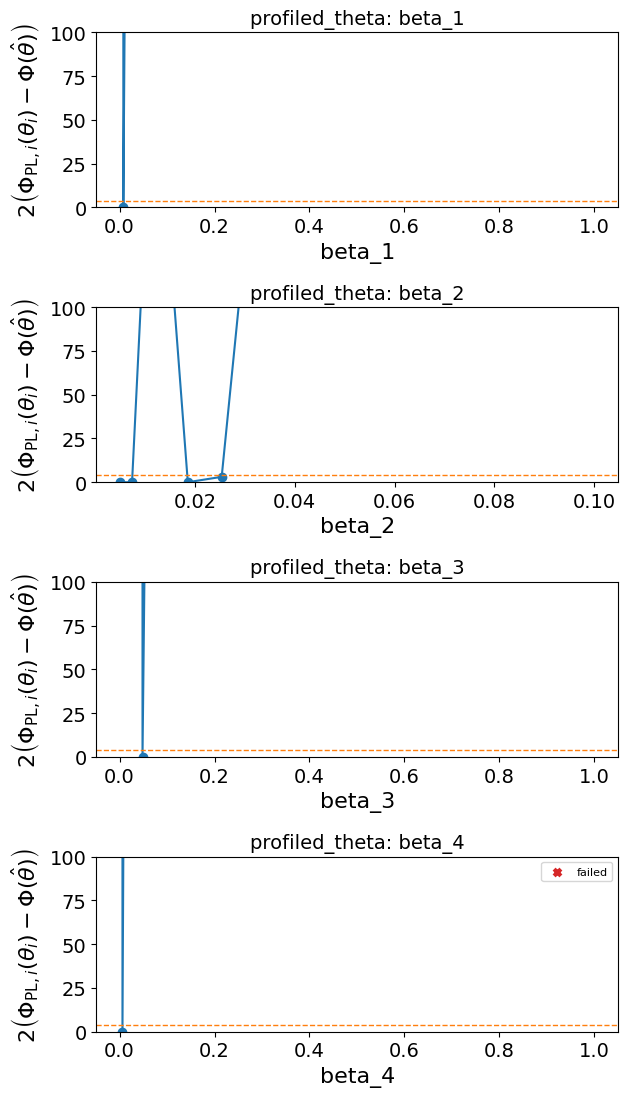

In [17]:
import scipy.stats as stats
import matplotlib.pyplot as plt
threshold = stats.chi2.ppf(float(0.95), df=1)
print(f"Chi-squared threshold for 95% confidence interval: {threshold:.4f}")

# Plot profile curves to file for terminal/non-GUI usage
fig, axes = parmest.graphics.profile_likelihood_plot(
    profile_results, alpha=0.95, show=False,
    ylabel=r"$2\left(\Phi_{\mathrm{PL},i}(\theta_i)-\Phi(\hat{\theta})\right)$", 
)
# Add ylim of threshold for plots
# axs is a 2D array because plt.subplots(..., squeeze=False)
ylims = [
    (0, 100),     # subplot 1
    (0, 100),     # subplot 2
    (0, 100),    # subplot 3
    (0, 100),    # subplot 4
]
for ax, ylim in zip(axes[:, 0], ylims):
    ax.set_ylim(*ylim)

# # Set xlims for all subplots
# xlims = [
#     (0, 0.05),    # subplot 1
#     (0, 0.01),    # subplot 2
#     (0, 0.1),    # subplot 3
#     (0, 0.01),    # subplot 4
# ]

# for ax, xlim in zip(axes[:, 0], xlims):
#     ax.set_xlim(*xlim)


plt.tight_layout()
plt.show()

How does the estimability of the reformulated model compare to the original model?

## L2 Regularization

Using the same prior from the [regularization notebook](parmest_regularization.ipynb), converted to the reformulated model parameters, add regularization and compare the optimal solution.

### REPARAMETRIZATION
m.beta_1 = Var(initialize=self.theta_initial["Ua"] * self.theta_initial["inv_CpH"], bounds=(0.01, 10))
m.beta_1.fix()
m.beta_2 = Var(initialize=self.theta_initial["Ub"] * self.theta_initial["inv_CpH"], bounds=(0.01, 10))
m.beta_2.fix()
m.beta_3 = Var(initialize=self.theta_initial["Ub"] * self.theta_initial["inv_CpS"], bounds=(0.01, 10))
m.beta_3.fix()
m.beta_4 = Var(initialize=self.alpha * pyovalue(m.P1) * self.theta_initial["inv_CpH"], bounds=(0.01, 10))
m.beta_4.fix()

In [18]:
# Original prior:
import numpy as np
import pandas as pd

# ---- Physically intuitive guesses (Cp-space) ----
theta_phys = pd.Series({
    "Ua": 0.030,   # W/K, ambient loss from heater node
    "Ub": 0.018,   # W/K, heater-to-sensor coupling
    "CpH": 7.5,    # J/K, heater thermal mass
    "CpS": 0.22,   # J/K, sensor thermal mass
})
# Default values for alpha and P1
alpha = 0.00016  # K/W, heater efficiency
P1 = 200         # W, maximum heater power


# Transform to estimator parameterization [Ua, Ub, inv_CpH, inv_CpS]
theta0_phys_reparam = pd.Series({
    "beta_1": theta_phys["Ua"]/theta_phys["CpH"],
    "beta_2": theta_phys["Ub"]/theta_phys["CpH"],
    "beta_3": theta_phys["Ub"]/theta_phys["CpS"],
    "beta_4": alpha / theta_phys["CpH"] * P1,
})

# Define diagonal covariance matrix
cov_x = pd.DataFrame(
    np.diag([0.02, 0.01, 0.05, 0.05]),
    index=["beta_1","beta_2","beta_3","beta_4"],
    columns=["beta_1","beta_2","beta_3","beta_4"],
)

# Invert to get the physically informed prior_FIM
prior_FIM_phys = pd.DataFrame(
    np.linalg.inv(cov_x.values),
    index=cov_x.index,
    columns=cov_x.columns,
)

# Optional scaling factor to tune regularization strength
prior_weight = 2
prior_FIM_phys = prior_weight * prior_FIM_phys


print("theta0_phys_reparam:", theta0_phys_reparam)
print("prior_FIM_phys:\n", prior_FIM_phys)

theta0_phys_reparam: beta_1    0.004000
beta_2    0.002400
beta_3    0.081818
beta_4    0.004267
dtype: float64
prior_FIM_phys:
         beta_1  beta_2  beta_3  beta_4
beta_1   100.0     0.0     0.0     0.0
beta_2     0.0   200.0     0.0     0.0
beta_3     0.0     0.0    40.0     0.0
beta_4     0.0     0.0     0.0    40.0


In [19]:
### BEGIN SOLUTION
pest_regL2 = parmest.Estimator([TC_Lab_sine_exp], obj_function='SSE_weighted', 
                                    tee=True, solver_options=solver_options, regularization='L2', 
                                    prior_FIM=prior_FIM_phys, theta_ref=theta0_phys_reparam)

obj_phys, theta_phys_est = pest_regL2.theta_est()

print("\nL2 (physical prior) objective:", obj_phys)
print("L2 (physical prior) theta:\n", theta_phys_est)
### END SOLUTION

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000
max_cpu_time=30


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-

In [20]:
# Compare to unregularized estimation results
print("\nUnregularized objective:", obj)
print("Unregularized theta:\n", theta)
print("\nL2 (physical prior) objective:", obj_phys)
print("L2 (physical prior) theta:\n", theta_phys_est)


Unregularized objective: 53.77399284580833
Unregularized theta:
 beta_1    0.013276
beta_2    0.021589
beta_3    0.028714
beta_4    0.010187
dtype: float64

L2 (physical prior) objective: 430.21210302119874
L2 (physical prior) theta:
 beta_1    0.007457
beta_2    0.005000
beta_3    0.051123
beta_4    0.005722
dtype: float64
